In [1]:
import torch
import model as mc
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import matplotlib.pyplot as plt 
from mosqlient.scoring import Scorer


pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


columns_to_normalize_enso = ['casos','epiweek', 'biome', 'enso']

columns_to_normalize = ['casos','epiweek', 'biome']

predict_n = 36
max_epiweek = 16
    
boxcox = False

TEST_YEAR = 2023

In [2]:
media = True
min_year = 2015
doenca = 'dengue'
#model_name = 'enso'

enso = prep.load_enso_weekly()
df = prep.load_cases_data(filename= f'./data/{doenca}.csv.gz')

In [3]:
from pathlib import Path

def make_pred(
    df_reg_agg,
    df_reg,
    enso,
    doenca,
    region,
    TEST_YEAR,
    columns_to_normalize,
    model_name,
    media=True
):

    pred_path = Path(
        f"predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv.gz"
    )

    if pred_path.exists():

        print(f"Loading {pred_path}")

        df_preds1 = pd.read_csv(
            pred_path,
            index_col=0,
            parse_dates=True
        )

        df_preds1.date = pd.to_datetime(df_preds1.date)

    else:

        model1 = mc.load_model(
            region,
            TEST_YEAR,
            doenca,
            model_name,
            predict_n,
            max_epiweek,
            device
        )

        df_preds1 = mc.sum_regions_predictions(
            model1,
            df_reg,
            enso,
            TEST_YEAR,
            columns_to_normalize,
            max_epiweek=max_epiweek,
            boxcox=boxcox,
            n_passes=500,
            min_year=min_year,
            media=media
        )

        df_preds1.to_csv(pred_path)

    score = Scorer(
        api_key='',
        df_true=df_reg_agg,
        pred=df_preds1,
    )

    mean_sc1 = score.wis[1]['pred']

    return df_preds1, mean_sc1



Sul
Loading predictions/preds_dengue_Sul_2023_base.csv.gz
Loading predictions/preds_dengue_Sul_2023_enso_media.csv.gz


/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


Loading predictions/preds_dengue_Sul_2023_mix.csv.gz


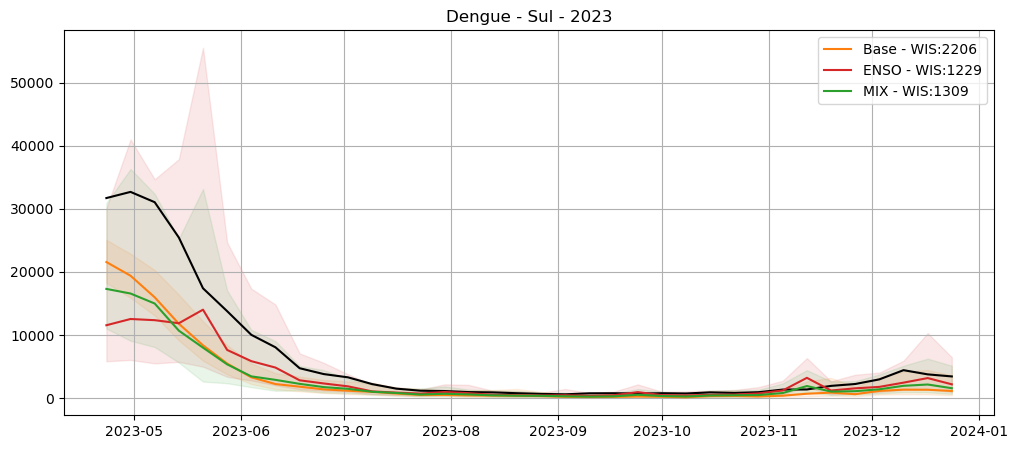

Sudeste
Loading predictions/preds_dengue_Sudeste_2023_base.csv.gz
Loading predictions/preds_dengue_Sudeste_2023_enso_media.csv.gz
Loading predictions/preds_dengue_Sudeste_2023_mix.csv.gz


/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


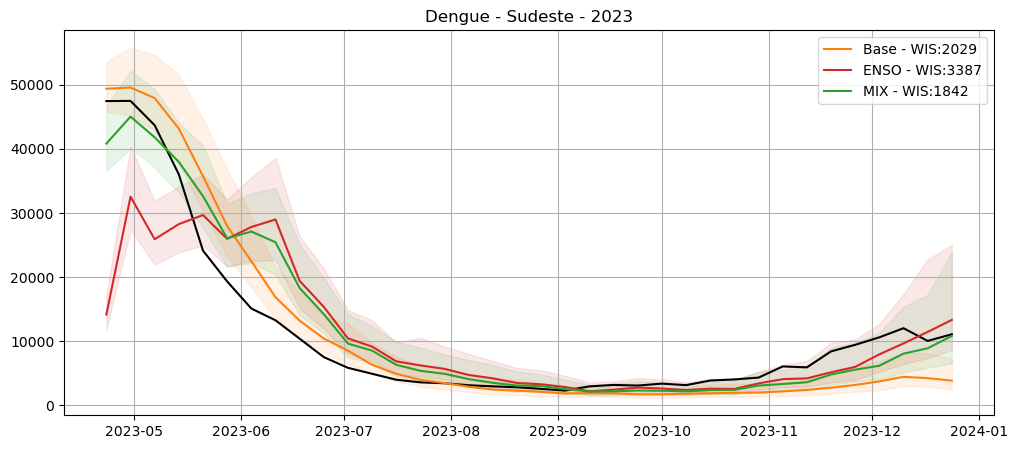

Nordeste
Loading predictions/preds_dengue_Nordeste_2023_base.csv.gz
Loading predictions/preds_dengue_Nordeste_2023_enso_media.csv.gz
Loading predictions/preds_dengue_Nordeste_2023_mix.csv.gz


/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


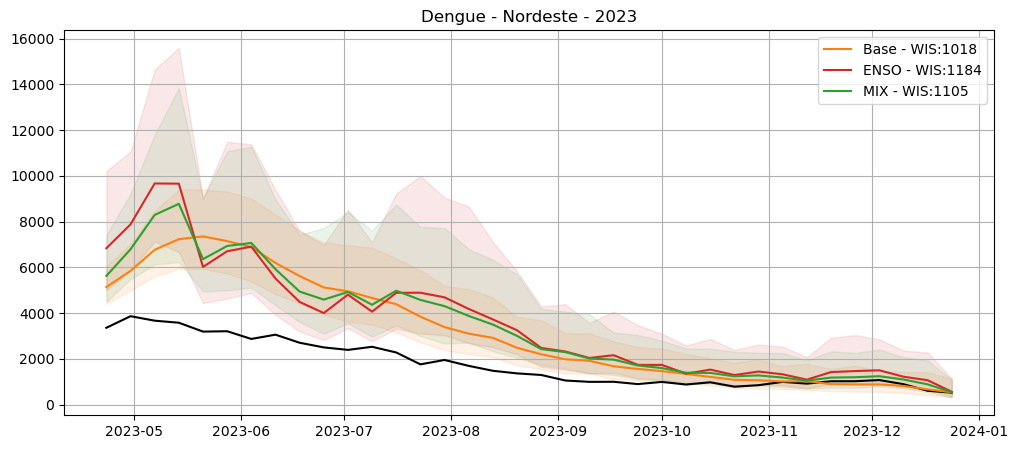

Centro-Oeste
Loading predictions/preds_dengue_Centro-Oeste_2023_base.csv.gz
Loading predictions/preds_dengue_Centro-Oeste_2023_enso_media.csv.gz
Loading predictions/preds_dengue_Centro-Oeste_2023_mix.csv.gz


/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


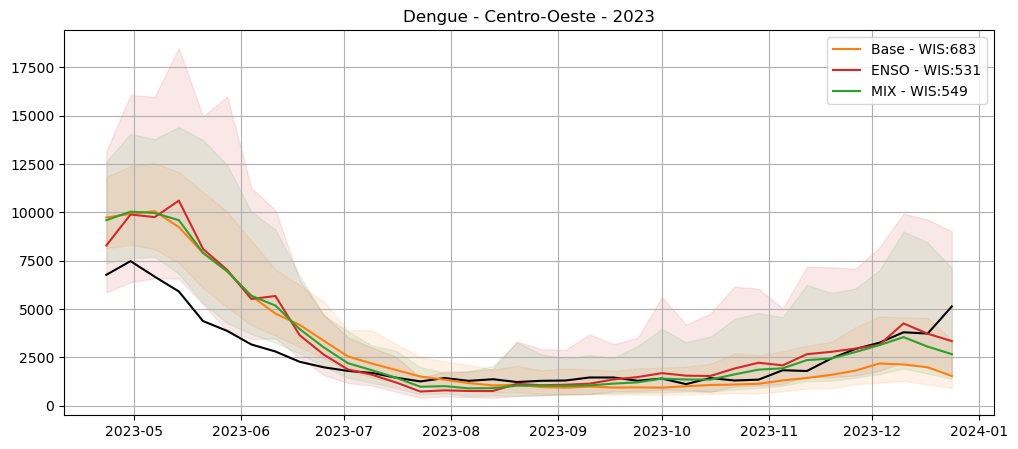

Norte
Loading predictions/preds_dengue_Norte_2023_base.csv.gz
Loading predictions/preds_dengue_Norte_2023_enso_media.csv.gz
Loading predictions/preds_dengue_Norte_2023_mix.csv.gz


/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(
/tmp/ipykernel_114873/1354749589.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_preds1 = pd.read_csv(


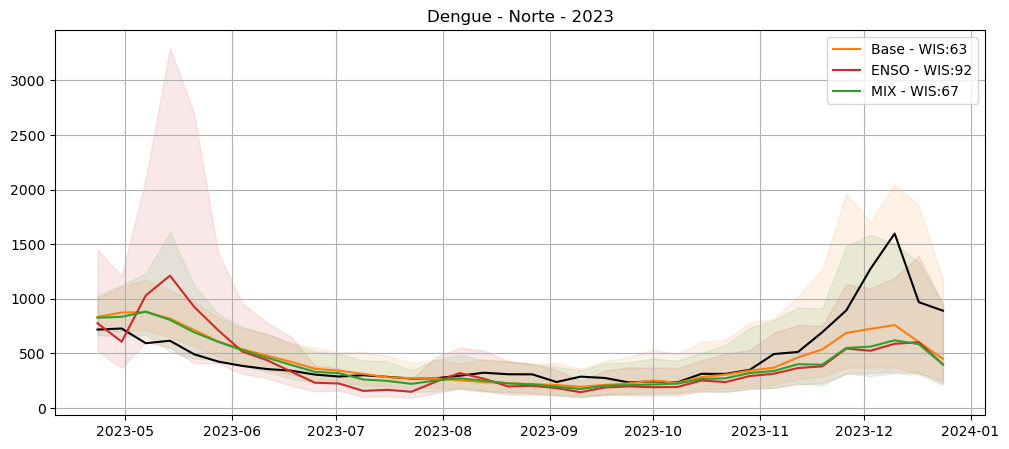

In [5]:
for region in regioes_estados.keys(): 

    print(region)

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_reg_agg = df_reg.groupby(['date', 'epiweek'])[['casos']].sum().reset_index()
    df_reg_agg = df_reg_agg.loc[(df_reg_agg.epiweek >= int(f'{TEST_YEAR}17')) & (df_reg_agg.epiweek <= int(f'{TEST_YEAR}52'))]

    df_preds1, mean_sc1 = make_pred(df_reg_agg, df_reg, None, doenca, region, TEST_YEAR, columns_to_normalize, model_name = 'base', media = True )

    df_preds2, mean_sc2 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'enso_media', media = True )

    df_preds3, mean_sc3 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'mix', media = True )


    _,ax=plt.subplots(figsize = (12,5))

    ax.plot(df_reg_agg.date, df_reg_agg.casos, color = 'black')

    ax.plot(df_preds1.date, df_preds1.pred, color = 'tab:orange', label = f'Base - WIS:{int(mean_sc1)}')
    ax.fill_between(df_preds1.date, df_preds1.lower_90, df_preds1.upper_90, color = 'tab:orange', alpha = 0.1)


    ax.plot(df_preds2.date, df_preds2.pred, color = 'tab:red', label = f'ENSO - WIS:{int(mean_sc2)}')
    ax.fill_between(df_preds2.date, df_preds2.lower_90, df_preds2.upper_90, color = 'tab:red', alpha = 0.1)

    ax.plot(df_preds3.date, df_preds3.pred, color = 'tab:green', label = f'MIX - WIS:{int(mean_sc3)}')
    ax.fill_between(df_preds3.date, df_preds3.lower_90, df_preds3.upper_90, color = 'tab:green', alpha = 0.1)

    ax.legend()
    ax.grid()
    ax.set_title(f'{doenca.capitalize()} - {region} - {TEST_YEAR}' )

    plt.savefig(f'figures/comp_models_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

    plt.show()


Chikungunya

In [ ]:
doenca = 'chikungunya'
df = prep.load_cases_data(filename= f'./data/{doenca}.csv.gz')

for region in regioes_estados.keys(): 

    print(region)

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_reg_agg = df_reg.groupby(['date', 'epiweek'])[['casos']].sum().reset_index()
    df_reg_agg = df_reg_agg.loc[(df_reg_agg.epiweek >= int(f'{TEST_YEAR}17')) & (df_reg_agg.epiweek <= int(f'{TEST_YEAR}52'))]

    df_preds1, mean_sc1 = make_pred(df_reg_agg, df_reg, None, doenca, region, TEST_YEAR, columns_to_normalize, model_name = 'base', media = True )

    df_preds4, mean_sc4 = make_pred(df_reg_agg, df_reg, None, doenca, region, TEST_YEAR, columns_to_normalize, model_name = 'base_transf', media = True )

    df_preds2, mean_sc2 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'enso_media', media = True )
    
    df_preds3, mean_sc3 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = 'enso_media_transf', media = True )


    _,ax=plt.subplots()

    ax.plot(df_reg_agg.date, df_reg_agg.casos, color = 'black')

    ax.plot(df_preds1.date, df_preds1.pred, color = 'tab:orange', label = f'Base - WIS:{int(mean_sc1)}')
    #ax.fill_between(df_preds1.date, df_preds1.lower_90, df_preds1.upper_90, color = 'tab:orange', alpha = 0.1)


    ax.plot(df_preds4.date, df_preds4.pred, color = 'tab:blue', label = f'Base TRANSF - WIS:{int(mean_sc1)}')
    #ax.fill_between(df_preds4.date, df_preds4.lower_90, df_preds1.upper_90, color = 'tab:blue', alpha = 0.1)

    ax.plot(df_preds2.date, df_preds2.pred, color = 'tab:red', label = f'ENSO - WIS:{int(mean_sc2)}')
    #ax.fill_between(df_preds2.date, df_preds2.lower_90, df_preds2.upper_90, color = 'tab:red', alpha = 0.1)

    ax.plot(df_preds3.date, df_preds3.pred, color = 'tab:green', label = f'ENSO TRANSF - WIS:{int(mean_sc2)}')
    #ax.fill_between(df_preds3.date, df_preds3.lower_90, df_preds3.upper_90, color = 'tab:green', alpha = 0.1)

    ax.legend()
    ax.set_title(f'{region} - {doenca}')

    plt.savefig(f'figures/comp_models_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

    plt.show()